In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
df_time = pd.read_csv("Initial_Project_Forecasting_Model.csv")
print("Dataset loaded with shape:", df_time.shape)
df_time.head()

Dataset loaded with shape: (5342, 27)


,Unnamed: 0,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Company_Name,Company_Profit,...,frequent_buyer,Month,Week,DayOfWeek,IsWeekend,RevenuePerUnit,MonthlySales_x,Rolling3MonthSales,MonthlySales_y,MonthlySales
0,2640.0,2641.0,30.0,1.0,10.0,2020-11-05,152598.866271,-0.028092,Quantum Holdings 30,35620.0,...,1,11,45,3,0,-0.002809,-12.529019,-12.529019,-12.529019,-12.529019
1,3471.0,3472.0,Unknown,1.0,3.0,2020-11-12,132107.996519,-1.075220,Elite Network 6,36967.0,...,1,11,46,3,0,-0.358407,-12.529019,-12.529019,-12.529019,-12.529019
2,3471.0,3472.0,Unknown,1.0,3.0,2020-11-12,132107.996519,-1.075220,Green Enterprises 8,107952.0,...,1,11,46,3,0,-0.358407,-12.529019,-12.529019,-12.529019,-12.529019
3,3471.0,3472.0,Unknown,1.0,3.0,2020-11-12,132107.996519,-1.075220,Quantum Holdings 14,78322.0,...,1,11,46,3,0,-0.358407,-12.529019,-12.529019,-12.529019,-12.529019
4,3471.0,3472.0,Unknown,1.0,3.0,2020-11-12,132107.996519,-1.075220,Sky Network 18,68892.0,...,1,11,46,3,0,-0.358407,-12.529019,-12.529019,-12.529019,-12.529019


In [3]:
# Check for missing values
print(df_time.isna().sum())

# Quick info
df_time.info()

Unnamed: 0                 0
Transaction_ID             0
Company_ID                 0
Product_ID                 0
Quantity                   0
Transaction_Date           0
Product_Price_x            0
Total_Cost                 0
Company_Name             241
Company_Profit             0
Address                  241
Product_Name             422
Product_Price_y          422
total_transactions         0
total_spent                0
avg_transaction_value      0
recency_days               0
frequent_buyer             0
Month                      0
Week                       0
DayOfWeek                  0
IsWeekend                  0
RevenuePerUnit             0
MonthlySales_x             0
Rolling3MonthSales         0
MonthlySales_y             0
MonthlySales               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5342 entries, 0 to 5341
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -

In [23]:
# Check numeric columns and fill missing values

numeric_cols = ['Quantity','Product_Price_x','Company_Profit','Rolling3MonthSales']
for col in numeric_cols:
    df_time[col] = df_time[col].fillna(df_time[col].median())

In [24]:
# Creating 6 Month Forecast Data

features = ['Month','Week','IsWeekend','Quantity','Product_Price_x','Company_Profit','Rolling3MonthSales']
X = df_time[features].fillna(0)
y = df_time['MonthlySales'].fillna(0)

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [13]:
# Approximate months 10–15 for 6-month forecast
future_6months = pd.DataFrame({
    'Month': [10,11,12,1,2,3],
    'Week': [40,44,48,1,5,9],  # approximate week numbers
    'IsWeekend': [0]*6,
    'Quantity': [df_time['Quantity'].mean()]*6,
    'Product_Price_x': [df_time['Product_Price_x'].mean()]*6,
    'Company_Profit': [df_time['Company_Profit'].mean()]*6,
    'Rolling3MonthSales': [df_time['Rolling3MonthSales'].mean()]*6
})

In [15]:
# Predict next 6 months
future_6months_predictions = model.predict(future_6months)

# Create forecast table
forecast_6months = pd.DataFrame({
    'Month': ['Month 1','Month 2','Month 3','Month 4','Month 5','Month 6'],
    'Predicted_Sales': future_6months_predictions
})
print(forecast_6months)

     Month  Predicted_Sales
0  Month 1        -1.624861
1  Month 2        -1.679264
2  Month 3        -1.733668
3  Month 4        -1.236054
4  Month 5        -1.290457
5  Month 6        -1.344861


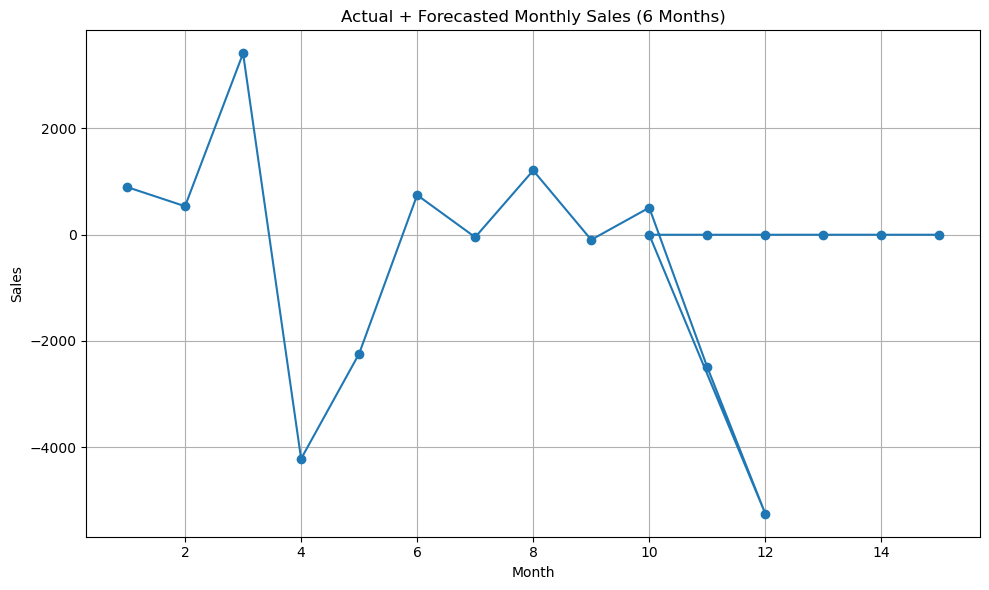

In [16]:
# Historical monthly sales
past_months = df_time.groupby('Month')['MonthlySales'].sum().reset_index()

# Combine past and forecast
combined_sales = pd.concat([
    past_months[['Month','MonthlySales']].rename(columns={'MonthlySales':'Sales'}),
    pd.DataFrame({'Month': range(10,16), 'Sales': future_6months_predictions})
], ignore_index=True)

plt.figure(figsize=(10,6))
plt.plot(combined_sales['Month'], combined_sales['Sales'], marker='o')
plt.title("Actual + Forecasted Monthly Sales (6 Months)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

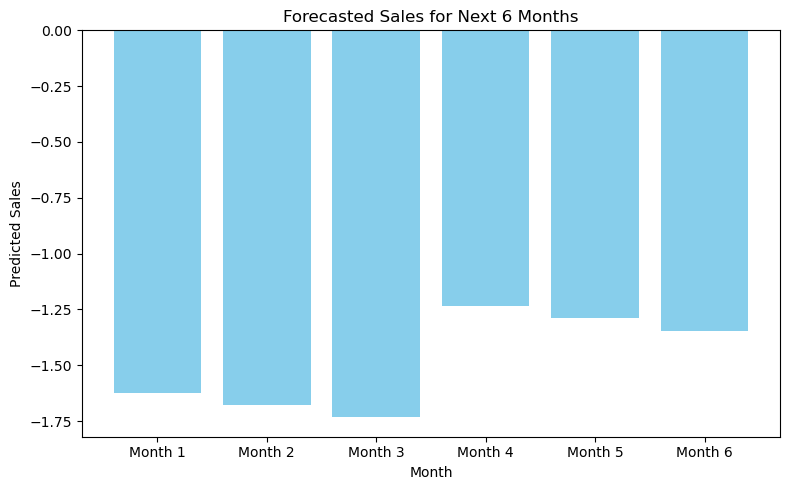

In [18]:
#Bar chart: Forecasted Sales Only

plt.figure(figsize=(8,5))
plt.bar(forecast_6months['Month'], forecast_6months['Predicted_Sales'], color='skyblue')
plt.title("Forecasted Sales for Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()